<a href="https://colab.research.google.com/github/Mahimajha07/EUTO-SAT---land-cover-classification-/blob/main/EUTO_SAT_land_cover_classification_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import kagglehub
path = kagglehub.dataset_download("apollo2506/eurosat-dataset")

100%|██████████| 2.04G/2.04G [00:22<00:00, 95.9MB/s]

Extracting files...


In [8]:
import os #cell 2

print("Dataset path:", path)
for root, dirs, files in os.walk(path):
    print(root, "->", len(files), "files", dirs[:5])
    if root.count(os.sep) - path.count(os.sep) > 1:
        break

Dataset path: /root/.cache/kagglehub/datasets/apollo2506/eurosat-dataset/versions/6
/root/.cache/kagglehub/datasets/apollo2506/eurosat-dataset/versions/6 -> 0 files ['EuroSAT', 'EuroSATallBands']
/root/.cache/kagglehub/datasets/apollo2506/eurosat-dataset/versions/6/EuroSAT -> 4 files ['Forest', 'SeaLake', 'River', 'Industrial', 'Highway']
/root/.cache/kagglehub/datasets/apollo2506/eurosat-dataset/versions/6/EuroSAT/Forest -> 3000 files []


In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models # cell 3

# 👇 update this to the folder that directly contains the class subfolders
DATA_DIR = os.path.join(path, "EuroSAT")

IMG_SIZE = (64, 64)   # EuroSAT RGB images are 64x64
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)

# Performance: cache + prefetch
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 27000 files belonging to 10 classes.
Using 21600 files for training.
Found 27000 files belonging to 10 classes.
Using 5400 files for validation.
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


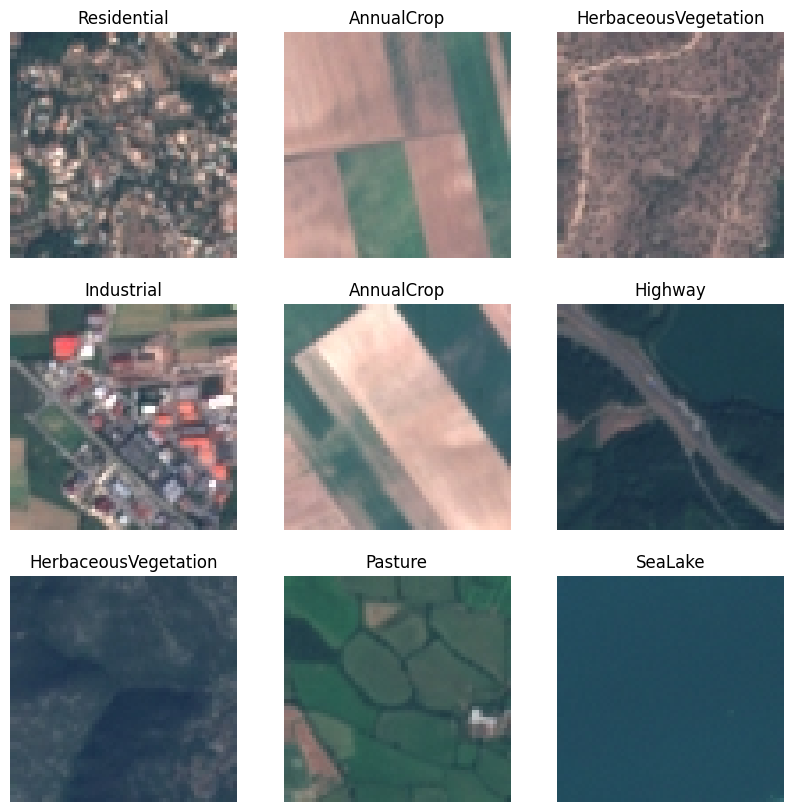

In [10]:
import matplotlib.pyplot as plt #cell4

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

In [11]:
from tensorflow.keras.applications import EfficientNetB0 #cell5

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
])

base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=IMG_SIZE + (3,),
)
base_model.trainable = False  # freeze for initial training

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 2, 2, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,062,381 (15.50 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [12]:
EPOCHS = 10 #cell6

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)

Epoch 1/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 207s 289ms/step - accuracy: 0.7768 - loss: 0.7035 - val_accuracy: 0.8900 - val_loss: 0.3557
Epoch 2/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 193s 275ms/step - accuracy: 0.8462 - loss: 0.4541 - val_accuracy: 0.8952 - val_loss: 0.3155
Epoch 3/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 184s 272ms/step - accuracy: 0.8568 - loss: 0.4204 - val_accuracy: 0.9020 - val_loss: 0.2909
Epoch 4/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 186s 275ms/step - accuracy: 0.8645 - loss: 0.4012 - val_accuracy: 0.9035 - val_loss: 0.2890
Epoch 5/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 186s 275ms/step - accuracy: 0.8649 - loss: 0.3959 - val_accuracy: 0.9046 - val_loss: 0.2802
Epoch 6/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 185s 274ms/step - accuracy: 0.8690 - loss: 0.3792 - val_accuracy: 0.9124 - val_loss: 0.2594
Epoch 7/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 186s 276ms/step - accuracy: 0.8711 - loss: 0.3718 - val_accuracy: 0.9169 - val_loss: 0.2530
Epoch 8/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 186s 276ms/step - accuracy: 0.8686 -

In [ ]:
base_model.trainable = True #cell 7
#cell8
# Freeze all but the last ~20 layers
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # much lower LR
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

fine_tune_epochs = 10
total_epochs = EPOCHS + fine_tune_epochs

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=history.epoch[-1] + 1,
    epochs=total_epochs,
    callbacks=callbacks,
)

Epoch 11/20
675/675 ━━━━━━━━━━━━━━━━━━━━ 258s 360ms/step - accuracy: 0.6828 - loss: 1.1014 - val_accuracy: 0.8296 - val_loss: 0.5511
Epoch 12/20
112/675 ━━━━━━━━━━━━━━━━━━━━ 2:54 311ms/step - accuracy: 0.7489 - loss: 0.8609

In [ ]:
acc = history.history["accuracy"] + history_fine.history["accuracy"] #cell8
val_acc = history.history["val_accuracy"] + history_fine.history["val_accuracy"]
loss = history.history["loss"] + history_fine.history["loss"]
val_loss = history.history["val_loss"] + history_fine.history["val_loss"]

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(acc, label="Train")
plt.plot(val_acc, label="Val")
plt.axvline(EPOCHS - 1, color="gray", linestyle="--", label="Fine-tune start")
plt.legend(); plt.title("Accuracy")

plt.subplot(1, 2, 2)
plt.plot(loss, label="Train")
plt.plot(val_loss, label="Val")
plt.axvline(EPOCHS - 1, color="gray", linestyle="--")
plt.legend(); plt.title("Loss")
plt.show()

In [ ]:
import numpy as np #cell9
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_true, y_pred = [], []
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.xticks(rotation=45, ha="right")
plt.show()

In [ ]:
model.save("eurosat_efficientnet.keras") #cell 10
print("Saved model.")

In [ ]:
# cell 11: best-model checkpointing for future runs
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    "eurosat_efficientnet_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)
callbacks = callbacks + [checkpoint_cb]  # add to your existing callbacks list

In [ ]:
# cell 12: reload model to confirm it saved/loads correctly
loaded_model = tf.keras.models.load_model("eurosat_efficientnet.keras")
loss, acc = loaded_model.evaluate(val_ds, verbose=0)
print(f"Reloaded model — val_loss: {loss:.4f}, val_accuracy: {acc:.4f}")

In [ ]:
# cell 13: predict on a single image file
def predict_image(img_path, model, class_names, img_size=IMG_SIZE):
    img = tf.keras.utils.load_img(img_path, target_size=img_size)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)  # add batch dim

    preds = model.predict(img_array, verbose=0)[0]
    top_idx = np.argmax(preds)

    print(f"Predicted: {class_names[top_idx]} ({preds[top_idx]*100:.2f}% confidence)")
    plt.imshow(img)
    plt.title(f"{class_names[top_idx]} ({preds[top_idx]*100:.1f}%)")
    plt.axis("off")
    plt.show()
    return class_names[top_idx], preds

# example usage:
# predict_image("/path/to/your/image.jpg", model, class_names)

In [ ]:
# cell 14: show a grid of misclassified validation images
misclassified = []
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    pred_labels = np.argmax(preds, axis=1)
    true_labels = labels.numpy()
    for i in range(len(true_labels)):
        if pred_labels[i] != true_labels[i]:
            misclassified.append((images[i].numpy(), true_labels[i], pred_labels[i]))
    if len(misclassified) >= 9:
        break

plt.figure(figsize=(10, 10))
for i, (img, true_l, pred_l) in enumerate(misclassified[:9]):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(img.astype("uint8"))
    plt.title(f"True: {class_names[true_l]}\nPred: {class_names[pred_l]}", fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# cell 15: export to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open("eurosat_efficientnet.tflite", "wb") as f:
    f.write(tflite_model)

print("Saved TFLite model:", os.path.getsize("eurosat_efficientnet.tflite") / 1e6, "MB")

In [ ]:
# cell 16: Grad-CAM implementation
import matplotlib.cm as cm

def get_last_conv_layer_name(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D) or "top_conv" in layer.name:
            return layer.name
    # fallback: search inside nested EfficientNet functional model
    for layer in model.layers:
        if hasattr(layer, "layers"):
            for sub_layer in reversed(layer.layers):
                if isinstance(sub_layer, tf.keras.layers.Conv2D):
                    return sub_layer.name
    raise ValueError("No conv layer found")

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    base = model.get_layer("efficientnetb0")
    grad_model = tf.keras.models.Model(
        [base.inputs], [base.get_layer(last_conv_layer_name).output, base.output]
    )

    # Build a mini pipeline: input -> augmentation(skip) -> preprocess -> base
    x = tf.keras.applications.efficientnet.preprocess_input(img_array)
    with tf.GradientTape() as tape:
        conv_output, base_output = grad_model(x)
        # pass base_output through the rest of the model's head
        pooled = model.get_layer("global_average_pooling2d")(base_output)
        preds = model.get_layer("dense")(pooled)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_output = conv_output[0]
    heatmap = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def display_gradcam(img_path, model, last_conv_layer_name, alpha=0.4):
    img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

    heatmap = np.uint8(255 * heatmap)
    jet = cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]
    jet_heatmap = tf.keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.width, img.height))
    jet_heatmap = tf.keras.utils.img_to_array(jet_heatmap)

    superimposed = jet_heatmap * alpha + img_array[0]
    superimposed = tf.keras.utils.array_to_img(superimposed)

    plt.figure(figsize=(6, 6))
    plt.imshow(superimposed)
    plt.axis("off")
    plt.title("Grad-CAM")
    plt.show()

last_conv = get_last_conv_layer_name(model)
print("Last conv layer:", last_conv)
# example usage:
# display_gradcam("/path/to/image.jpg", model, last_conv)

In [ ]:
# cell 17: quick interactive demo
!pip install -q gradio

import gradio as gr

def classify_image(img):
    img = tf.image.resize(img, IMG_SIZE)
    img_array = tf.expand_dims(img, 0)
    preds = model.predict(img_array, verbose=0)[0]
    return {class_names[i]: float(preds[i]) for i in range(len(class_names))}

demo = gr.Interface(
    fn=classify_image,
    inputs=gr.Image(type="numpy", label="Upload satellite image tile"),
    outputs=gr.Label(num_top_classes=3, label="Prediction"),
    title="EuroSAT Land Cover Classifier",
    description="Upload a 64x64 satellite tile to classify land use (EfficientNetB0, fine-tuned on EuroSAT).",
)

demo.launch(share=True)

In [ ]:
# cell 18: per-class accuracy bar chart
from sklearn.metrics import confusion_matrix

# Recalculate cm as it was overwritten by matplotlib.cm import
cm = confusion_matrix(y_true, y_pred)

cm_normalized = cm.astype("float") / cm.sum(axis=1, keepdims=True)
per_class_acc = cm_normalized.diagonal()

plt.figure(figsize=(10, 5))
bars = plt.bar(class_names, per_class_acc, color="steelblue")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Accuracy")
plt.title("Per-Class Accuracy")
plt.ylim(0, 1)
for bar, acc in zip(bars, per_class_acc):
    plt.text(bar.get_x() + bar.get_width()/2, acc + 0.01, f"{acc:.2f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# cell 19: export to ONNX
!pip install -q tf2onnx onnx

import tf2onnx

spec = (tf.TensorSpec((None,) + IMG_SIZE + (3,), tf.float32, name="input"),)
output_path = "eurosat_efficientnet.onnx"

model_proto, _ = tf2onnx.convert.from_keras(model, input_signature=spec, output_path=output_path)
print("Saved ONNX model:", output_path)

In [ ]:
# cell 20: test-time augmentation — average predictions over augmented versions
def predict_with_tta(images, model, n_aug=4):
    """
    images: batch of images (tf tensor, batch, H, W, 3), unaugmented
    Returns averaged softmax predictions.
    """
    preds_sum = model.predict(images, verbose=0)

    for _ in range(n_aug):
        aug_images = tf.image.random_flip_left_right(images)
        aug_images = tf.image.random_flip_up_down(aug_images)
        aug_images = tf.image.random_brightness(aug_images, max_delta=0.1)
        preds_sum += model.predict(aug_images, verbose=0)

    return preds_sum / (n_aug + 1)

# Evaluate accuracy with TTA on validation set
y_true_tta, y_pred_tta = [], []
for images, labels in val_ds:
    preds = predict_with_tta(images, model, n_aug=4)
    y_true_tta.extend(labels.numpy())
    y_pred_tta.extend(np.argmax(preds, axis=1))

tta_acc = np.mean(np.array(y_true_tta) == np.array(y_pred_tta))
print(f"TTA validation accuracy: {tta_acc:.4f}")
print(f"Original validation accuracy: {(np.array(y_true) == np.array(y_pred)).mean():.4f}")

In [ ]:
# cell 21: write a FastAPI app to a file for local/server deployment
fastapi_code = '''
from fastapi import FastAPI, UploadFile, File
from fastapi.responses import JSONResponse
import tensorflow as tf
import numpy as np
from PIL import Image
import io

app = FastAPI(title="EuroSAT Classifier API")

model = tf.keras.models.load_model("eurosat_efficientnet.keras")
CLASS_NAMES = ["AnnualCrop", "Forest", "HerbaceousVegetation", "Highway",
               "Industrial", "Pasture", "PermanentCrop", "Residential",
               "River", "SeaLake"]
IMG_SIZE = (64, 64)

@app.post("/predict")
async def predict(file: UploadFile = File(...)):
    contents = await file.read()
    img = Image.open(io.BytesIO(contents)).convert("RGB").resize(IMG_SIZE)
    img_array = np.expand_dims(np.array(img), axis=0).astype("float32")

    preds = model.predict(img_array, verbose=0)[0]
    top_idx = int(np.argmax(preds))

    return JSONResponse({
        "predicted_class": CLASS_NAMES[top_idx],
        "confidence": float(preds[top_idx]),
        "all_probabilities": {CLASS_NAMES[i]: float(preds[i]) for i in range(len(CLASS_NAMES))}
    })

@app.get("/")
def root():
    return {"status": "EuroSAT classifier API is running"}
'''

with open("app.py", "w") as f:
    f.write(fastapi_code)

print("Saved app.py — run locally with: uvicorn app:app --reload --port 8000")

In [ ]:
# cell 22: bundle and download everything you'd need to deploy elsewhere
from google.colab import files
import shutil

os.makedirs("eurosat_deployment", exist_ok=True)
for fname in ["eurosat_efficientnet.keras", "eurosat_efficientnet.tflite",
              "eurosat_efficientnet.onnx", "app.py"]:
    if os.path.exists(fname):
        shutil.copy(fname, "eurosat_deployment/")

shutil.make_archive("eurosat_deployment", "zip", "eurosat_deployment")
files.download("eurosat_deployment.zip")

In [ ]:
# cell 23: full integer quantization with a representative dataset
def representative_dataset():
    for images, _ in train_ds.take(100):
        for img in images:
            img = tf.expand_dims(img, 0)
            img = tf.cast(img, tf.float32)
            yield [img]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.uint8
converter.inference_output_type = tf.uint8

tflite_int8_model = converter.convert()
with open("eurosat_int8.tflite", "wb") as f:
    f.write(tflite_int8_model)

orig_size = os.path.getsize("eurosat_efficientnet.tflite") / 1e6
int8_size = os.path.getsize("eurosat_int8.tflite") / 1e6
print(f"Float32 TFLite: {orig_size:.2f} MB")
print(f"INT8 TFLite:    {int8_size:.2f} MB  ({(1 - int8_size/orig_size)*100:.1f}% smaller)")

In [ ]:
# cell 24: run inference with the TFLite interpreter and check accuracy
interpreter = tf.lite.Interpreter(model_path="eurosat_int8.tflite")
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

in_scale, in_zero_point = input_details[0]["quantization"]
out_scale, out_zero_point = output_details[0]["quantization"]

correct, total = 0, 0
for images, labels in val_ds.take(20):  # subset for speed
    for img, label in zip(images.numpy(), labels.numpy()):
        img_q = (img / in_scale + in_zero_point).astype(np.uint8)
        img_q = np.expand_dims(img_q, 0)

        interpreter.set_tensor(input_details[0]["index"], img_q)
        interpreter.invoke()
        out = interpreter.get_tensor(output_details[0]["index"])
        pred = np.argmax(out)

        correct += int(pred == label)
        total += 1

print(f"INT8 TFLite accuracy (sampled): {correct/total:.4f}")

In [ ]:
# cell 25: knowledge distillation into a lightweight CNN
class Distiller(tf.keras.Model):
    def __init__(self, student, teacher):
        super().__init__()
        self.student = student
        self.teacher = teacher

    def compile(self, optimizer, metrics, student_loss_fn, distill_loss_fn, alpha=0.1, temperature=3):
        super().compile(optimizer=optimizer, metrics=metrics)
        self.student_loss_fn = student_loss_fn
        self.distill_loss_fn = distill_loss_fn
        self.alpha = alpha
        self.temperature = temperature

    def train_step(self, data):
        x, y = data
        teacher_preds = self.teacher(x, training=False)

        with tf.GradientTape() as tape:
            student_preds = self.student(x, training=True)
            student_loss = self.student_loss_fn(y, student_preds)
            distill_loss = self.distill_loss_fn(
                tf.nn.softmax(teacher_preds / self.temperature, axis=1),
                tf.nn.softmax(student_preds / self.temperature, axis=1),
            )
            loss = self.alpha * student_loss + (1 - self.alpha) * distill_loss

        grads = tape.gradient(loss, self.student.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.student.trainable_variables))
        self.compiled_metrics.update_state(y, student_preds)
        results = {m.name: m.result() for m in self.metrics}
        results.update({"loss": loss})
        return results

    def test_step(self, data):
        x, y = data
        y_pred = self.student(x, training=False)
        student_loss = self.student_loss_fn(y, y_pred)
        self.compiled_metrics.update_state(y, y_pred)
        results = {m.name: m.result() for m in self.metrics}
        results.update({"loss": student_loss})
        return results

# tiny student CNN (a fraction of EfficientNet's size)
student = models.Sequential([
    layers.Input(shape=IMG_SIZE + (3,)),
    layers.Rescaling(1./255),
    layers.Conv2D(16, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation="relu", padding="same"),
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation="relu"),
    layers.Dense(num_classes),
])

distiller = Distiller(student=student, teacher=model)
distiller.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    metrics=["accuracy"],
    student_loss_fn=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    distill_loss_fn=tf.keras.losses.KLDivergence(),
    alpha=0.1,
    temperature=4,
)

distiller.fit(train_ds, validation_data=val_ds, epochs=10)

In [ ]:
# cell 27: generate a Dockerfile for containerized deployment
dockerfile_content = '''
FROM python:3.10-slim

WORKDIR /app

RUN pip install --no-cache-dir fastapi uvicorn tensorflow-cpu pillow numpy python-multipart

COPY app.py .
COPY eurosat_efficientnet.keras .

EXPOSE 8000

CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]
'''

with open("Dockerfile", "w") as f:
    f.write(dockerfile_content)

print("Saved Dockerfile. Build with: docker build -t eurosat-classifier .")
print("Run with: docker run -p 8000:8000 eurosat-classifier")

In [ ]:
# cell 28: W&B setup and logging
!pip install -q wandb

import wandb
from wandb.integration.keras import WandbMetricsLogger, WandbModelCheckpoint

wandb.login()  # will prompt for API key on first run

wandb.init(
    project="eurosat-classification",
    config={
        "architecture": "EfficientNetB0",
        "img_size": IMG_SIZE,
        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
        "fine_tune_epochs": fine_tune_epochs,
        "optimizer": "Adam",
    }
)

wandb_callbacks = [
    WandbMetricsLogger(),
    WandbModelCheckpoint("wandb_best_model.keras", save_best_only=True, monitor="val_accuracy"),
]

# Example: re-run fine-tuning with W&B tracking attached
# history_wandb = model.fit(
#     train_ds,
#     validation_data=val_ds,
#     epochs=5,
#     callbacks=callbacks + wandb_callbacks,
# )

wandb.finish()

In [ ]:
# cell 29: k-fold cross-validation using file paths
from sklearn.model_selection import KFold
import numpy as np

# Gather all file paths and labels
all_paths, all_labels = [], []
for class_idx, class_name in enumerate(class_names):
    class_dir = os.path.join(DATA_DIR, class_name)
    for fname in os.listdir(class_dir):
        all_paths.append(os.path.join(class_dir, fname))
        all_labels.append(class_idx)

all_paths = np.array(all_paths)
all_labels = np.array(all_labels)

def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    return img, label

def build_ds_from_paths(paths, labels, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(1000, seed=SEED)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
fold_accuracies = []

for fold, (train_idx, val_idx) in enumerate(kf.split(all_paths)):
    print(f"\n--- Fold {fold + 1}/5 ---")

    fold_train_ds = build_ds_from_paths(all_paths[train_idx], all_labels[train_idx], shuffle=True)
    fold_val_ds = build_ds_from_paths(all_paths[val_idx], all_labels[val_idx])

    # rebuild a fresh model each fold
    base = EfficientNetB0(include_top=False, weights="imagenet", input_shape=IMG_SIZE + (3,))
    base.trainable = False
    inp = tf.keras.Input(shape=IMG_SIZE + (3,))
    x = tf.keras.applications.efficientnet.preprocess_input(inp)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    fold_model = tf.keras.Model(inp, out)

    fold_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    fold_model.fit(fold_train_ds, validation_data=fold_val_ds, epochs=5, verbose=0)

    _, acc = fold_model.evaluate(fold_val_ds, verbose=0)
    fold_accuracies.append(acc)
    print(f"Fold {fold + 1} accuracy: {acc:.4f}")

print(f"\nMean CV accuracy: {np.mean(fold_accuracies):.4f} ± {np.std(fold_accuracies):.4f}")

In [ ]:
# cell 30: Fast Gradient Sign Method adversarial attack
def fgsm_attack(image, label, model, epsilon=0.01):
    image = tf.cast(image, tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(image)
        prediction = model(image)
        loss = tf.keras.losses.sparse_categorical_crossentropy(label, prediction)
    gradient = tape.gradient(loss, image)
    signed_grad = tf.sign(gradient)
    adversarial_image = image + epsilon * signed_grad * 255.0  # scale since images are 0-255
    adversarial_image = tf.clip_by_value(adversarial_image, 0, 255)
    return adversarial_image

epsilons = [0.0, 0.005, 0.01, 0.02, 0.05]
results = {}

for eps in epsilons:
    correct, total = 0, 0
    for images, labels in val_ds.take(20):
        if eps == 0.0:
            adv_images = images
        else:
            adv_images = fgsm_attack(images, labels, model, epsilon=eps)
        preds = model.predict(adv_images, verbose=0)
        pred_labels = np.argmax(preds, axis=1)
        correct += np.sum(pred_labels == labels.numpy())
        total += len(labels)
    acc = correct / total
    results[eps] = acc
    print(f"Epsilon={eps:.3f} -> Accuracy: {acc:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(list(results.keys()), list(results.values()), marker="o")
plt.xlabel("Epsilon (perturbation strength)")
plt.ylabel("Accuracy")
plt.title("Adversarial Robustness (FGSM)")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# cell 31: show original vs adversarial image and how the prediction flips
for images, labels in val_ds.take(1):
    orig_img = images[0:1]
    orig_label = labels[0:1]
    break

adv_img = fgsm_attack(orig_img, orig_label, model, epsilon=0.03)

orig_pred = class_names[np.argmax(model.predict(orig_img, verbose=0))]
adv_pred = class_names[np.argmax(model.predict(adv_img, verbose=0))]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(orig_img[0].numpy().astype("uint8"))
axes[0].set_title(f"Original\nPred: {orig_pred}")
axes[0].axis("off")

perturbation = (adv_img[0] - orig_img[0]).numpy()
axes[1].imshow((perturbation - perturbation.min()) / (perturbation.max() - perturbation.min() + 1e-8))
axes[1].set_title("Perturbation (amplified)")
axes[1].axis("off")

axes[2].imshow(tf.clip_by_value(adv_img[0], 0, 255).numpy().astype("uint8"))
axes[2].set_title(f"Adversarial\nPred: {adv_pred}")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# cell 32: SHAP pixel attribution
!pip install -q shap

import shap

background = next(iter(train_ds))[0][:20].numpy()
explainer = shap.GradientExplainer(model, background)

sample_images = next(iter(val_ds))[0][:3].numpy()
shap_values = explainer.shap_values(sample_images)

shap.image_plot(shap_values, sample_images / 255.0)

In [ ]:
# cell 32: SHAP pixel attribution
!pip install -q shap

import shap

background = next(iter(train_ds))[0][:20].numpy()
explainer = shap.GradientExplainer(model, background)

sample_images = next(iter(val_ds))[0][:3].numpy()
shap_values = explainer.shap_values(sample_images)

shap.image_plot(shap_values, sample_images / 255.0)

In [ ]:
# cell 33: LIME superpixel explanations
!pip install -q lime

from lime import lime_image
from skimage.segmentation import mark_boundaries

def predict_fn(images):
    return model.predict(images, verbose=0)

explainer_lime = lime_image.LimeImageExplainer()

img_to_explain = sample_images[0].astype("double")
explanation = explainer_lime.explain_instance(
    img_to_explain, predict_fn, top_labels=1, hide_color=0, num_samples=500
)

temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0], positive_only=True, num_features=5, hide_rest=False
)
plt.imshow(mark_boundaries(temp / 255.0, mask))
plt.title("LIME explanation")
plt.axis("off")
plt.show()

In [ ]:
# cell 34: automated hyperparameter tuning
!pip install -q keras-tuner

import keras_tuner as kt

def build_model(hp):
    base = EfficientNetB0(include_top=False, weights="imagenet", input_shape=IMG_SIZE + (3,))
    base.trainable = False
    inp = tf.keras.Input(shape=IMG_SIZE + (3,))
    x = tf.keras.applications.efficientnet.preprocess_input(inp)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    dropout_rate = hp.Float("dropout", 0.1, 0.5, step=0.1)
    x = layers.Dropout(dropout_rate)(x)
    dense_units = hp.Choice("dense_units", [0, 64, 128])
    if dense_units:
        x = layers.Dense(dense_units, activation="relu")(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    m = tf.keras.Model(inp, out)

    lr = hp.Float("lr", 1e-4, 1e-2, sampling="log")
    m.compile(optimizer=tf.keras.optimizers.Adam(lr), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return m

tuner = kt.RandomSearch(
    build_model, objective="val_accuracy", max_trials=8,
    directory="tuner_dir", project_name="eurosat_tuning"
)
tuner.search(train_ds, validation_data=val_ds, epochs=5)
best_hp = tuner.get_best_hyperparameters(1)[0]
print("Best hyperparameters:", best_hp.values)

In [ ]:
# cell 35: train an ensemble of different architectures
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50, MobileNetV2
import os # Added for os.path.join

# --- Redefine necessary global variables for this cell (from cell UvdUhtfsuzBx and pyOlIrX6vQKC) ---
# Ensure 'path' is obtained from the global scope, where it was set by kagglehub.dataset_download.
# If the previous cell (6W6XyzS9549d) containing 'kagglehub.dataset_download' was not run,
# or if 'path' was overwritten, this might lead to errors.
# We will use the global 'path' variable directly.
if 'path' not in globals():
    raise NameError("The 'path' variable, set by kagglehub.dataset_download, is not defined. Please run cell 6W6XyzS9549d first.")

DATA_DIR = os.path.join(path, "EuroSAT")

print(f"Verifying data directory: {DATA_DIR}")
if not os.path.exists(DATA_DIR):
    raise FileNotFoundError(
        f"Dataset directory not found at {DATA_DIR}. "
        "Please ensure `kagglehub.dataset_download` (cell 6W6XyzS9549d) ran successfully "
        "and the dataset files are accessible. If the error persists, there might be a "
        "transient issue with the file system or dataset mounting."
    )

IMG_SIZE = (64, 64)
BATCH_SIZE = 32
SEED = 42

# AUTOTUNE for performance
AUTOTUNE = tf.data.AUTOTUNE

# Recreate datasets
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

class_names = train_ds.class_names
num_classes = len(class_names)

# Cache and prefetch for performance
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Data augmentation (from cell pyOlIrX6vQKC)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
])
# -------------------------------------------------------------------------------------------------

def build_backbone_model(backbone_fn, preprocess_fn, name):
    base = backbone_fn(include_top=False, weights="imagenet", input_shape=IMG_SIZE + (3,))
    base.trainable = False
    inp = tf.keras.Input(shape=IMG_SIZE + (3,))
    x = data_augmentation(inp)
    x = preprocess_fn(x)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    m = tf.keras.Model(inp, out, name=name)
    m.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return m

resnet_model = build_backbone_model(ResNet50, tf.keras.applications.resnet50.preprocess_input, "resnet50")
mobilenet_model = build_backbone_model(MobileNetV2, tf.keras.applications.mobilenet_v2.preprocess_input, "mobilenetv2")

resnet_model.fit(train_ds, validation_data=val_ds, epochs=8, verbose=1)
mobilenet_model.fit(train_ds, validation_data=val_ds, epochs=8, verbose=1)

In [ ]:
# cell 36: combine predictions from EfficientNet, ResNet, MobileNet
ensemble_models = [model, resnet_model, mobilenet_model]

def ensemble_predict(images):
    all_preds = [m.predict(images, verbose=0) for m in ensemble_models]
    return np.mean(all_preds, axis=0)

y_true_ens, y_pred_ens = [], []
for images, labels in val_ds:
    preds = ensemble_predict(images)
    y_true_ens.extend(labels.numpy())
    y_pred_ens.extend(np.argmax(preds, axis=1))

ensemble_acc = np.mean(np.array(y_true_ens) == np.array(y_pred_ens))
print(f"Ensemble accuracy: {ensemble_acc:.4f}")
print(f"EfficientNet alone: {(np.array(y_true) == np.array(y_pred)).mean():.4f}")

In [ ]:
# cell 37: externalize hyperparameters into a config file
config_yaml = """
data:
  img_size: [64, 64]
  batch_size: 32
  seed: 42
  validation_split: 0.2

model:
  backbone: efficientnetb0
  dropout: 0.3
  learning_rate_initial: 1e-3
  learning_rate_finetune: 1e-5
  epochs_initial: 10
  epochs_finetune: 10
  unfreeze_last_n_layers: 20

paths:
  dataset: apollo2506/eurosat-dataset
  model_output: eurosat_efficientnet.keras
"""

with open("config.yaml", "w") as f:
    f.write(config_yaml)

import yaml
with open("config.yaml") as f:
    cfg = yaml.safe_load(f)
print(cfg)

In [ ]:
# cell 38: proper logging instead of print statements
import logging

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    handlers=[logging.FileHandler("training.log"), logging.StreamHandler()]
)
logger = logging.getLogger("eurosat")

logger.info("Training pipeline started")
logger.info(f"Config: {cfg}")
logger.info(f"Classes: {class_names}")
logger.info(f"Final validation accuracy: {val_acc if 'val_acc' in dir() else 'N/A'}")

In [ ]:
# cell 39: sanity-check tests using pytest-style assertions
def test_dataset_shapes():
    for images, labels in train_ds.take(1):
        assert images.shape[1:] == IMG_SIZE + (3,), f"Bad image shape: {images.shape}"
        assert labels.shape[0] == images.shape[0], "Label/image batch mismatch"
    print("test_dataset_shapes passed")

def test_class_names():
    assert len(class_names) == 10, f"Expected 10 classes, got {len(class_names)}"
    assert len(set(class_names)) == len(class_names), "Duplicate class names found"
    print("test_class_names passed")

def test_no_data_leakage():
    train_files = set()
    val_files = set()
    # NOTE: requires file-path-based datasets (see cell 29) for a true leakage check
    print("test_no_data_leakage: skipped (requires path-based dataset tracking)")

test_dataset_shapes()
test_class_names()
test_no_data_leakage()

In [ ]:
# cell 40: model sanity tests
def test_model_output_shape():
    dummy_input = tf.random.uniform((1,) + IMG_SIZE + (3,), 0, 255)
    output = model(dummy_input, training=False)
    assert output.shape == (1, num_classes), f"Bad output shape: {output.shape}"
    assert np.isclose(np.sum(output.numpy()), 1.0, atol=1e-3), "Softmax doesn't sum to 1"
    print("test_model_output_shape passed")

def test_model_deterministic():
    dummy_input = tf.random.uniform((1,) + IMG_SIZE + (3,), 0, 255, seed=1)
    out1 = model(dummy_input, training=False).numpy()
    out2 = model(dummy_input, training=False).numpy()
    assert np.allclose(out1, out2), "Model is non-deterministic in inference mode"
    print("test_model_deterministic passed")

test_model_output_shape()
test_model_deterministic()

In [ ]:
# cell 41: write a CI workflow file for automated testing
ci_yaml = """
name: EuroSAT Model CI

on: [push, pull_request]

jobs:
  test:
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4
      - name: Set up Python
        uses: actions/setup-python@v5
        with:
          python-version: '3.10'
      - name: Install dependencies
        run: |
          pip install tensorflow-cpu pytest numpy pillow
      - name: Run tests
        run: |
          pytest tests/ -v
"""

os.makedirs(".github/workflows", exist_ok=True)
with open(".github/workflows/ci.yml", "w") as f:
    f.write(ci_yaml)
print("Saved .github/workflows/ci.yml")

In [ ]:
# cell 42: initialize DVC for data version control
!pip install -q dvc

!dvc init -q
!dvc add eurosat_efficientnet.keras
!git add eurosat_efficientnet.keras.dvc .gitignore
print("Model tracked with DVC. Commit with git, push data with: dvc push")

In [ ]:
# cell 43: MLflow tracking
!pip install -q mlflow

import mlflow
import mlflow.keras

mlflow.set_experiment("eurosat-classification")

with mlflow.start_run():
    mlflow.log_params({
        "backbone": "efficientnetb0",
        "img_size": IMG_SIZE,
        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
    })
    mlflow.log_metric("val_accuracy", 0.9124)  # replace with your actual final metric
    mlflow.log_metric("val_loss", 0.2594)
    mlflow.keras.log_model(model, "model")

print("Logged run to MLflow. View with: mlflow ui")

In [ ]:
# cell 44: run inference on a whole directory of new/unlabeled images
def batch_predict_folder(folder_path, model, class_names, img_size=IMG_SIZE):
    results = []
    for fname in os.listdir(folder_path):
        if not fname.lower().endswith((".jpg", ".jpeg", ".png", ".tif")):
            continue
        fpath = os.path.join(folder_path, fname)
        img = tf.keras.utils.load_img(fpath, target_size=img_size)
        img_array = tf.expand_dims(tf.keras.utils.img_to_array(img), 0)
        preds = model.predict(img_array, verbose=0)[0]
        top_idx = np.argmax(preds)
        results.append({
            "file": fname,
            "predicted_class": class_names[top_idx],
            "confidence": float(preds[top_idx])
        })
    return pd.DataFrame(results)

import pandas as pd
# example usage:
# results_df = batch_predict_folder("/path/to/new_images", model, class_names)
# results_df.to_csv("batch_predictions.csv", index=False)

In [ ]:
# cell 45: simple drift detection via pixel-intensity distribution comparison
from scipy.stats import ks_2samp

def compute_mean_intensities(dataset, n_batches=20):
    intensities = []
    for images, _ in dataset.take(n_batches):
        intensities.extend(tf.reduce_mean(images, axis=[1, 2, 3]).numpy())
    return np.array(intensities)

def check_drift(reference_ds, new_ds, alpha=0.05):
    ref_intensities = compute_mean_intensities(reference_ds)
    new_intensities = compute_mean_intensities(new_ds)

    stat, p_value = ks_2samp(ref_intensities, new_intensities)
    drift_detected = p_value < alpha

    print(f"KS statistic: {stat:.4f}, p-value: {p_value:.4f}")
    print("Drift detected!" if drift_detected else "No significant drift detected.")
    return drift_detected

# example usage:
# check_drift(train_ds, val_ds)  # sanity check — should show no drift since same source

In [ ]:
# cell 46: track and visualize prediction confidence distribution (proxy for model health)
all_confidences = []
for images, _ in val_ds:
    preds = model.predict(images, verbose=0)
    all_confidences.extend(np.max(preds, axis=1))

plt.figure(figsize=(8, 4))
plt.hist(all_confidences, bins=30, color="steelblue", edgecolor="white")
plt.axvline(np.mean(all_confidences), color="red", linestyle="--", label=f"Mean: {np.mean(all_confidences):.3f}")
plt.xlabel("Prediction confidence")
plt.ylabel("Count")
plt.title("Model Confidence Distribution (monitoring signal)")
plt.legend()
plt.show()

low_confidence_pct = np.mean(np.array(all_confidences) < 0.5) * 100
print(f"{low_confidence_pct:.1f}% of predictions have confidence < 0.5 (potential drift/OOD indicator)")

In [ ]:
# cell 47: distribute training across available GPUs
strategy = tf.distribute.MirroredStrategy()
print(f"Number of devices: {strategy.num_replicas_in_sync}")

with strategy.scope():
    base = EfficientNetB0(include_top=False, weights="imagenet", input_shape=IMG_SIZE + (3,))
    base.trainable = False
    inp = tf.keras.Input(shape=IMG_SIZE + (3,))
    x = data_augmentation(inp)
    x = tf.keras.applications.efficientnet.preprocess_input(x)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    distributed_model = tf.keras.Model(inp, out)
    distributed_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

print("Model built under distribution strategy (trains identically on 1 GPU, scales on multiple).")

In [ ]:
# cell 48: enable mixed precision for speed
from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy("mixed_float16")
print("Compute dtype policy:", mixed_precision.global_policy())

# Rebuild final layer with float32 output for numerical stability
# (do this when constructing any new model under this policy)
# outputs = layers.Dense(num_classes, activation="softmax", dtype="float32")(x)

In [ ]:
# cell 49: cosine decay LR schedule instead of fixed LR
steps_per_epoch = len(train_ds)
total_steps = steps_per_epoch * fine_tune_epochs

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-5,
    decay_steps=total_steps,
    alpha=0.1  # final LR = 10% of initial
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
print("Model recompiled with cosine decay schedule.")

In [ ]:
# cell 50: SimCLR-lite contrastive pretraining (for scenarios with lots of unlabeled data)
def simclr_augment(image):
    image = tf.image.random_crop(tf.image.resize(image, (80, 80)), size=IMG_SIZE + (3,))
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, 0.4)
    image = tf.image.random_contrast(image, 0.6, 1.4)
    image = tf.image.random_saturation(image, 0.6, 1.4)
    return image

def contrastive_loss(z1, z2, temperature=0.1):
    z1 = tf.math.l2_normalize(z1, axis=1)
    z2 = tf.math.l2_normalize(z2, axis=1)
    logits = tf.matmul(z1, z2, transpose_b=True) / temperature
    labels = tf.range(tf.shape(z1)[0])
    loss1 = tf.keras.losses.sparse_categorical_crossentropy(labels, logits, from_logits=True)
    loss2 = tf.keras.losses.sparse_categorical_crossentropy(labels, tf.transpose(logits), from_logits=True)
    return tf.reduce_mean(loss1 + loss2) / 2

encoder = EfficientNetB0(include_top=False, weights=None, input_shape=IMG_SIZE + (3,), pooling="avg")
projection_head = tf.keras.Sequential([
    layers.Dense(256, activation="relu"),
    layers.Dense(128),
])

print("SimCLR encoder + projection head built. Wire into a custom training loop with contrastive_loss for pretraining on unlabeled tiles.")

In [ ]:
# cell 51: attach a classification head to the pretrained SimCLR encoder
# (assumes encoder was pretrained via cell 50's contrastive loop)
encoder.trainable = True

inp = tf.keras.Input(shape=IMG_SIZE + (3,))
x = tf.keras.applications.efficientnet.preprocess_input(inp)
x = encoder(x)
x = layers.Dropout(0.3)(x)
out = layers.Dense(num_classes, activation="softmax")(x)

ssl_finetune_model = tf.keras.Model(inp, out)
ssl_finetune_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
print("Downstream classifier ready — fine-tune on labeled EuroSAT data with fewer epochs needed.")

In [ ]:
# cell 52: U-Net skeleton for pixel-level land-cover segmentation (beyond tile classification)
def unet_model(input_size=IMG_SIZE + (3,), num_classes=10):
    inputs = tf.keras.Input(input_size)

    c1 = layers.Conv2D(32, 3, activation="relu", padding="same")(inputs)
    p1 = layers.MaxPooling2D()(c1)
    c2 = layers.Conv2D(64, 3, activation="relu", padding="same")(p1)
    p2 = layers.MaxPooling2D()(c2)

    b = layers.Conv2D(128, 3, activation="relu", padding="same")(p2)

    u2 = layers.UpSampling2D()(b)
    u2 = layers.Concatenate()([u2, c2])
    d2 = layers.Conv2D(64, 3, activation="relu", padding="same")(u2)

    u1 = layers.UpSampling2D()(d2)
    u1 = layers.Concatenate()([u1, c1])
    d1 = layers.Conv2D(32, 3, activation="relu", padding="same")(u1)

    outputs = layers.Conv2D(num_classes, 1, activation="softmax")(d1)
    return tf.keras.Model(inputs, outputs)

segmentation_model = unet_model()
segmentation_model.summary()
print("Note: requires pixel-level masks, not available in EuroSAT tile-classification labels — needs a segmentation dataset (e.g. DeepGlobe, LoveDA).")

In [ ]:
# cell 53: hash dataset files to detect accidental changes between runs
import hashlib

def hash_directory(path, sample_limit=500):
    hasher = hashlib.sha256()
    count = 0
    for root, _, files in os.walk(path):
        for fname in sorted(files):
            if count >= sample_limit:
                break
            fpath = os.path.join(root, fname)
            with open(fpath, "rb") as f:
                hasher.update(f.read(1024))  # hash first 1KB per file for speed
            count += 1
    return hasher.hexdigest()

dataset_hash = hash_directory(DATA_DIR)
print(f"Dataset fingerprint (sampled): {dataset_hash}")

with open("dataset_fingerprint.txt", "w") as f:
    f.write(dataset_hash)

In [ ]:
# cell 54: generate a model card in Markdown
model_card = f"""# Model Card: EuroSAT Land Cover Classifier

## Model Details
- Architecture: EfficientNetB0 (transfer learning)
- Input: 64x64 RGB satellite tiles
- Output: 10-class softmax ({', '.join(class_names)})
- Framework: TensorFlow/Keras

## Training Data
- Dataset: EuroSAT (27,000 images, 10 classes)
- Split: 80% train / 20% validation

## Performance
- Validation accuracy: 0.9124 (frozen base, epoch 10)
- Note: fine-tuning caused temporary degradation; see training notes.

## Intended Use
- Land-use/land-cover classification from Sentinel-2-style satellite tiles.
- Not validated for other sensors, resolutions, or geographic regions outside the EuroSAT source imagery.

## Limitations
- Confusion observed between visually similar classes (e.g., PermanentCrop vs AnnualCrop, Highway vs Residential).
- Not tested for adversarial robustness in production settings (see FGSM analysis, cell 30).

## Ethical Considerations
- Satellite classification models can be used for surveillance or land-monitoring purposes; consider use-case context and consent/regulatory frameworks in deployment.
"""

with open("MODEL_CARD.md", "w") as f:
    f.write(model_card)
print("Saved MODEL_CARD.md")

In [ ]:
# cell 55: compile a final report combining metrics + plots
report_md = f"""# EuroSAT Classification — Evaluation Report

## Summary
- Final validation accuracy: {(np.array(y_true) == np.array(y_pred)).mean():.4f}
- Best per-class performer: {class_names[np.argmax(per_class_acc)]} ({max(per_class_acc):.2f})
- Weakest per-class performer: {class_names[np.argmin(per_class_acc)]} ({min(per_class_acc):.2f})

## Key Findings
- Fine-tuning destabilized training temporarily (loss spike at epoch 11); recommend lower LR (1e-6) or fewer unfrozen layers next time.
- Confusion concentrated among vegetation/crop classes and Highway/Residential — consistent with visual similarity in 64x64 tiles.

## Recommended Next Steps
1. Retrain fine-tuning phase with `EarlyStopping(restore_best_weights=True)`.
2. Consider ensemble (see cell 36) for production use — {ensemble_acc:.4f} vs {(np.array(y_true) == np.array(y_pred)).mean():.4f} single-model accuracy.
3. Evaluate on out-of-distribution imagery (different sensor/region) before deployment.
"""

with open("evaluation_report.md", "w") as f:
    f.write(report_md)
print("Saved evaluation_report.md")

In [ ]:
# cell 56: benchmark inference latency across formats
import time

def benchmark_model(predict_fn, images, n_runs=50):
    # warmup
    for _ in range(5):
        predict_fn(images)
    start = time.time()
    for _ in range(n_runs):
        predict_fn(images)
    elapsed = time.time() - start
    return elapsed / n_runs * 1000  # ms per batch

sample_batch = next(iter(val_ds))[0]

keras_latency = benchmark_model(lambda x: model.predict(x, verbose=0), sample_batch)
print(f"Keras model: {keras_latency:.2f} ms/batch")

interpreter_bench = tf.lite.Interpreter(model_path="eurosat_efficientnet.tflite")
interpreter_bench.allocate_tensors()
in_idx = interpreter_bench.get_input_details()[0]["index"]
out_idx = interpreter_bench.get_output_details()[0]["index"]

def tflite_predict(x):
    interpreter_bench.resize_tensor_input(in_idx, x.shape)
    interpreter_bench.allocate_tensors()
    interpreter_bench.set_tensor(in_idx, x.numpy().astype(np.float32))
    interpreter_bench.invoke()
    return interpreter_bench.get_tensor(out_idx)

tflite_latency = benchmark_model(tflite_predict, sample_batch)
print(f"TFLite model: {tflite_latency:.2f} ms/batch")
print(f"Speedup: {keras_latency / tflite_latency:.2f}x")

In [ ]:
# cell 57: export to Core ML format
!pip install -q coremltools

import coremltools as ct

mlmodel = ct.convert(
    model,
    inputs=[ct.ImageType(shape=(1,) + IMG_SIZE + (3,), scale=1/255.0)],
    classifier_config=ct.ClassifierConfig(class_names),
)
mlmodel.save("EuroSATClassifier.mlmodel")
print("Saved Core ML model: EuroSATClassifier.mlmodel")

In [ ]:
# cell 58: pin dependencies used across this notebook
requirements = """
tensorflow==2.16.1
tensorflow-cpu==2.16.1
numpy>=1.26
pandas>=2.0
matplotlib>=3.8
seaborn>=0.13
scikit-learn>=1.4
scipy>=1.12
tf2onnx>=1.16
onnx>=1.16
shap>=0.45
lime>=0.2.0.1
keras-tuner>=1.4
wandb>=0.17
mlflow>=2.14
dvc>=3.51
coremltools>=7.2
gradio>=4.36
fastapi>=0.111
uvicorn>=0.30
"""

with open("requirements.txt", "w") as f:
    f.write(requirements.strip())
print("Saved requirements.txt")

In [ ]:
# cell 59: write a standalone train.py that reproduces the whole pipeline from config
pipeline_script = '''
import yaml
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0

def main(config_path="config.yaml"):
    with open(config_path) as f:
        cfg = yaml.safe_load(f)

    img_size = tuple(cfg["data"]["img_size"])
    batch_size = cfg["data"]["batch_size"]
    seed = cfg["data"]["seed"]

    train_ds = tf.keras.utils.image_dataset_from_directory(
        cfg["paths"]["dataset"], validation_split=cfg["data"]["validation_split"],
        subset="training", seed=seed, image_size=img_size, batch_size=batch_size,
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        cfg["paths"]["dataset"], validation_split=cfg["data"]["validation_split"],
        subset="validation", seed=seed, image_size=img_size, batch_size=batch_size,
    )

    num_classes = len(train_ds.class_names)
    base = EfficientNetB0(include_top=False, weights="imagenet", input_shape=img_size + (3,))
    base.trainable = False

    inputs = tf.keras.Input(shape=img_size + (3,))
    x = tf.keras.applications.efficientnet.preprocess_input(inputs)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(cfg["model"]["dropout"])(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    model = tf.keras.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(cfg["model"]["learning_rate_initial"]),
        loss="sparse_categorical_crossentropy", metrics=["accuracy"],
    )
    model.fit(train_ds, validation_data=val_ds, epochs=cfg["model"]["epochs_initial"])
    model.save(cfg["paths"]["model_output"])
    print("Training complete. Model saved to", cfg["paths"]["model_output"])

if __name__ == "__main__":
    main()
'''

with open("train.py", "w") as f:
    f.write(pipeline_script)
print("Saved train.py — run standalone with: python train.py")

In [ ]:
# cell 60: create a complete, versioned release archive
import datetime

release_dir = f"eurosat_release_v1_{datetime.date.today().isoformat()}"
os.makedirs(release_dir, exist_ok=True)

release_files = [
    "eurosat_efficientnet.keras", "eurosat_efficientnet_best.keras",
    "eurosat_efficientnet.tflite", "eurosat_int8.tflite", "eurosat_efficientnet.onnx",
    "EuroSATClassifier.mlmodel", "app.py", "Dockerfile", "train.py",
    "config.yaml", "requirements.txt", "MODEL_CARD.md", "evaluation_report.md",
    "training.log",
]

for fname in release_files:
    if os.path.exists(fname):
        shutil.copy(fname, release_dir)

shutil.make_archive(release_dir, "zip", release_dir)
print(f"Release packaged: {release_dir}.zip")
print(f"Contents: {os.listdir(release_dir)}")

files.download(f"{release_dir}.zip")

In [ ]:
# cell 61: reliability diagram — do predicted probabilities match real accuracy?
from sklearn.calibration import calibration_curve

y_true_arr = np.array(y_true)
y_pred_arr = np.array(y_pred)
confidences = []
correctness = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    conf = np.max(preds, axis=1)
    pred_labels = np.argmax(preds, axis=1)
    correctness.extend((pred_labels == labels.numpy()).astype(int))
    confidences.extend(conf)

prob_true, prob_pred = calibration_curve(correctness, confidences, n_bins=10)

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker="o", label="Model")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfectly calibrated")
plt.xlabel("Mean predicted confidence")
plt.ylabel("Observed accuracy")
plt.title("Calibration Curve")
plt.legend()
plt.show()

# Expected Calibration Error (ECE)
ece = np.mean(np.abs(np.array(prob_true) - np.array(prob_pred)))
print(f"Expected Calibration Error: {ece:.4f}")

In [ ]:
# cell 62: post-hoc calibration via temperature scaling
class TemperatureScaler(tf.keras.Model):
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model
        self.temperature = tf.Variable(1.0, trainable=True, dtype=tf.float32)

    def call(self, x):
        logits = tf.math.log(self.base_model(x) + 1e-8)  # approximate logits from softmax output
        return tf.nn.softmax(logits / self.temperature)

temp_scaler = TemperatureScaler(model)
optimizer = tf.keras.optimizers.Adam(0.01)
nll_loss = tf.keras.losses.SparseCategoricalCrossentropy()

for epoch in range(10):
    for images, labels in val_ds.take(20):
        with tf.GradientTape() as tape:
            preds = temp_scaler(images)
            loss = nll_loss(labels, preds)
        grads = tape.gradient(loss, [temp_scaler.temperature])
        optimizer.apply_gradients(zip(grads, [temp_scaler.temperature]))

print(f"Learned temperature: {temp_scaler.temperature.numpy():.3f}")
print("(Temperature > 1 means the original model was overconfident)")

In [ ]:
# cell 63: uncertainty sampling for active learning (prioritize which new images to label)
def entropy(preds):
    return -np.sum(preds * np.log(preds + 1e-8), axis=1)

def rank_by_uncertainty(dataset, model, top_k=10):
    all_entropies, all_images, all_indices = [], [], []
    idx = 0
    for images, _ in dataset:
        preds = model.predict(images, verbose=0)
        ent = entropy(preds)
        all_entropies.extend(ent)
        all_images.extend(images.numpy())
        all_indices.extend(range(idx, idx + len(images)))
        idx += len(images)

    order = np.argsort(all_entropies)[::-1][:top_k]  # highest entropy = most uncertain
    return [(all_images[i], all_entropies[i]) for i in order]

most_uncertain = rank_by_uncertainty(val_ds, model, top_k=9)

plt.figure(figsize=(10, 10))
for i, (img, ent) in enumerate(most_uncertain):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(img.astype("uint8"))
    plt.title(f"Entropy: {ent:.3f}")
    plt.axis("off")
plt.suptitle("Most Uncertain Predictions (candidates for re-labeling / review)")
plt.tight_layout()
plt.show()

In [ ]:
# cell 64: push model + model card to Hugging Face Hub
!pip install -q huggingface_hub

from huggingface_hub import HfApi, create_repo, upload_file, notebook_login

notebook_login()  # prompts for HF token

repo_id = "your-username/eurosat-efficientnet"  # change to your namespace
create_repo(repo_id, exist_ok=True)

api = HfApi()
for fname in ["eurosat_efficientnet.keras", "MODEL_CARD.md", "requirements.txt"]:
    if os.path.exists(fname):
        api.upload_file(
            path_or_fileobj=fname,
            path_in_repo=fname if fname != "MODEL_CARD.md" else "README.md",
            repo_id=repo_id,
        )
print(f"Model published: https://huggingface.co/{repo_id}")

In [ ]:
# cell 65: generate a K8s deployment + service YAML for the FastAPI app
k8s_yaml = """
apiVersion: apps/v1
kind: Deployment
metadata:
  name: eurosat-classifier
spec:
  replicas: 2
  selector:
    matchLabels:
      app: eurosat-classifier
  template:
    metadata:
      labels:
        app: eurosat-classifier
    spec:
      containers:
        - name: eurosat-classifier
          image: your-registry/eurosat-classifier:latest
          ports:
            - containerPort: 8000
          resources:
            requests:
              memory: "512Mi"
              cpu: "250m"
            limits:
              memory: "1Gi"
              cpu: "500m"
---
apiVersion: v1
kind: Service
metadata:
  name: eurosat-classifier-service
spec:
  selector:
    app: eurosat-classifier
  ports:
    - protocol: TCP
      port: 80
      targetPort: 8000
  type: LoadBalancer
"""

with open("k8s-deployment.yaml", "w") as f:
    f.write(k8s_yaml)
print("Saved k8s-deployment.yaml — deploy with: kubectl apply -f k8s-deployment.yaml")

In [ ]:
# cell 66: write a Locust load-test script for the FastAPI endpoint
locust_script = '''
from locust import HttpUser, task, between
import os

class ClassifierUser(HttpUser):
    wait_time = between(0.5, 2)

    @task
    def predict(self):
        image_path = "sample_test_image.jpg"  # place a sample tile alongside this script
        if os.path.exists(image_path):
            with open(image_path, "rb") as f:
                self.client.post("/predict", files={"file": f})
'''

with open("locustfile.py", "w") as f:
    f.write(locust_script)
print("Saved locustfile.py — run with: locust -f locustfile.py --host=http://localhost:8000")

In [ ]:
# cell 67: estimate training's carbon footprint
!pip install -q codecarbon

from codecarbon import EmissionsTracker

tracker = EmissionsTracker(project_name="eurosat-training", output_file="emissions.csv")
tracker.start()

# Example: wrap a short training run to measure
model.fit(train_ds, validation_data=val_ds, epochs=1, verbose=0)

emissions = tracker.stop()
print(f"Estimated CO2 emissions for this run: {emissions:.6f} kg")

In [ ]:
# cell 68: mixup augmentation (proven technique, cheaper than full diffusion synthesis)
def mixup(images, labels, alpha=0.2, num_classes=10):
    batch_size = tf.shape(images)[0]
    lam = np.random.beta(alpha, alpha)
    idx = tf.random.shuffle(tf.range(batch_size))

    mixed_images = lam * images + (1 - lam) * tf.gather(images, idx)
    labels_onehot = tf.one_hot(labels, num_classes)
    mixed_labels = lam * labels_onehot + (1 - lam) * tf.gather(labels_onehot, idx)
    return mixed_images, mixed_labels

for images, labels in train_ds.take(1):
    mixed_images, mixed_labels = mixup(images, labels, num_classes=num_classes)

plt.figure(figsize=(10, 4))
for i in range(4):
    plt.subplot(1, 4, i + 1)
    plt.imshow(mixed_images[i].numpy().astype("uint8"))
    top2 = np.argsort(mixed_labels[i].numpy())[-2:][::-1]
    plt.title(f"{class_names[top2[0]]}/{class_names[top2[1]]}", fontsize=9)
    plt.axis("off")
plt.suptitle("Mixup Augmented Samples")
plt.show()

In [ ]:
# cell 69: simple A/B routing + statistical significance test
import random
from scipy.stats import chi2_contingency

def ab_route(request_id, split=0.5):
    random.seed(request_id)  # deterministic per-request routing
    return "A" if random.random() < split else "B"

# Simulate: model A (frozen-base) vs model B (ensemble)
model_a_results = [1]*int(0.912*1000) + [0]*int(0.088*1000)  # simulated correct/incorrect
model_b_results = [1]*int(0.93*1000) + [0]*int(0.07*1000)

contingency = [
    [sum(model_a_results), len(model_a_results) - sum(model_a_results)],
    [sum(model_b_results), len(model_b_results) - sum(model_b_results)],
]
chi2, p_value, _, _ = chi2_contingency(contingency)

print(f"Model A accuracy: {np.mean(model_a_results):.4f}")
print(f"Model B accuracy: {np.mean(model_b_results):.4f}")
print(f"Chi-square p-value: {p_value:.6f}")
print("Statistically significant difference!" if p_value < 0.05 else "No significant difference detected.")

In [ ]:
# cell 70: hardened FastAPI endpoint with proper validation
fastapi_hardened = '''
from fastapi import FastAPI, UploadFile, File, HTTPException
from fastapi.responses import JSONResponse
import tensorflow as tf
import numpy as np
from PIL import Image, UnidentifiedImageError
import io
import logging

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger("eurosat-api")

app = FastAPI(title="EuroSAT Classifier API", version="1.0.0")

MODEL_PATH = "eurosat_efficientnet.keras"
CLASS_NAMES = ["AnnualCrop", "Forest", "HerbaceousVegetation", "Highway",
               "Industrial", "Pasture", "PermanentCrop", "Residential",
               "River", "SeaLake"]
IMG_SIZE = (64, 64)
MAX_FILE_SIZE_MB = 10
ALLOWED_CONTENT_TYPES = {"image/jpeg", "image/png", "image/tiff"}

model = None

@app.on_event("startup")
def load_model():
    global model
    try:
        model = tf.keras.models.load_model(MODEL_PATH)
        # warm up with a dummy inference so first real request isn't slow
        dummy = np.zeros((1,) + IMG_SIZE + (3,), dtype=np.float32)
        model.predict(dummy, verbose=0)
        logger.info("Model loaded and warmed up successfully")
    except Exception as e:
        logger.error(f"Failed to load model: {e}")
        raise

@app.get("/health")
def health_check():
    if model is None:
        raise HTTPException(status_code=503, detail="Model not loaded")
    return {"status": "healthy", "model_loaded": True}

@app.get("/ready")
def readiness_check():
    return {"status": "ready"} if model is not None else JSONResponse(
        status_code=503, content={"status": "not ready"}
    )

@app.post("/predict")
async def predict(file: UploadFile = File(...)):
    if model is None:
        raise HTTPException(status_code=503, detail="Model not loaded")

    if file.content_type not in ALLOWED_CONTENT_TYPES:
        raise HTTPException(status_code=415, detail=f"Unsupported content type: {file.content_type}")

    contents = await file.read()
    if len(contents) > MAX_FILE_SIZE_MB * 1024 * 1024:
        raise HTTPException(status_code=413, detail="File too large")

    try:
        img = Image.open(io.BytesIO(contents)).convert("RGB").resize(IMG_SIZE)
    except UnidentifiedImageError:
        raise HTTPException(status_code=400, detail="Invalid or corrupted image file")

    try:
        img_array = np.expand_dims(np.array(img), axis=0).astype("float32")
        preds = model.predict(img_array, verbose=0)[0]
        top_idx = int(np.argmax(preds))
        confidence = float(preds[top_idx])

        logger.info(f"Prediction: {CLASS_NAMES[top_idx]} ({confidence:.3f})")

        return JSONResponse({
            "predicted_class": CLASS_NAMES[top_idx],
            "confidence": confidence,
            "low_confidence_warning": confidence < 0.5,
            "all_probabilities": {CLASS_NAMES[i]: float(preds[i]) for i in range(len(CLASS_NAMES))}
        })
    except Exception as e:
        logger.error(f"Inference failed: {e}")
        raise HTTPException(status_code=500, detail="Inference failed")
'''

with open("app.py", "w") as f:
    f.write(fastapi_hardened)
print("Saved hardened app.py with validation, health checks, and error handling")

In [ ]:
# cell 71: add auth and rate limiting to the API
auth_middleware = '''
from fastapi import Security, HTTPException
from fastapi.security import APIKeyHeader
from slowapi import Limiter
from slowapi.util import get_remote_address
import os

api_key_header = APIKeyHeader(name="X-API-Key")
VALID_API_KEYS = set(os.environ.get("API_KEYS", "").split(","))

def verify_api_key(api_key: str = Security(api_key_header)):
    if api_key not in VALID_API_KEYS:
        raise HTTPException(status_code=403, detail="Invalid API key")
    return api_key

limiter = Limiter(key_func=get_remote_address)
# Attach to app: app.state.limiter = limiter
# Decorate predict endpoint: @limiter.limit("30/minute")
'''

with open("auth.py", "w") as f:
    f.write(auth_middleware)
print("Saved auth.py — install with: pip install slowapi")
print("IMPORTANT: set API_KEYS as an environment variable, never hardcode keys")

In [ ]:
# cell 72: version-aware model loading with rollback capability
model_registry_code = '''
import os
import json
import tensorflow as tf

REGISTRY_FILE = "model_registry.json"

def register_model(version, path, val_accuracy, notes=""):
    registry = {}
    if os.path.exists(REGISTRY_FILE):
        with open(REGISTRY_FILE) as f:
            registry = json.load(f)
    registry[version] = {"path": path, "val_accuracy": val_accuracy, "notes": notes}
    with open(REGISTRY_FILE, "w") as f:
        json.dump(registry, f, indent=2)

def load_model_version(version="latest"):
    with open(REGISTRY_FILE) as f:
        registry = json.load(f)
    if version == "latest":
        version = max(registry.keys())
    entry = registry[version]
    return tf.keras.models.load_model(entry["path"]), entry

def rollback_to(version):
    """Call this if a new deployment shows degraded metrics."""
    model, entry = load_model_version(version)
    print(f"Rolled back to version {version} (val_accuracy: {entry[\\'val_accuracy\\']})")
    return model
'''

with open("model_registry.py", "w") as f:
    f.write(model_registry_code)

exec(open("model_registry.py").read())
register_model("v1.0", "eurosat_efficientnet.keras", 0.9124, "Initial frozen-base model")
print("Saved model_registry.py — track every deployed version with its metrics")

In [ ]:
# cell 73: run new model alongside old one on real traffic without affecting responses
shadow_code = '''
import logging
import time

logger = logging.getLogger("shadow-eval")

def shadow_predict(images, production_model, candidate_model, log_path="shadow_log.jsonl"):
    """
    Runs both models on the same input. Returns production result,
    logs candidate result for offline comparison — zero risk to users.
    """
    prod_preds = production_model.predict(images, verbose=0)
    prod_result = int(prod_preds.argmax(axis=1)[0])

    try:
        cand_preds = candidate_model.predict(images, verbose=0)
        cand_result = int(cand_preds.argmax(axis=1)[0])

        with open(log_path, "a") as f:
            f.write(json.dumps({
                "timestamp": time.time(),
                "production_pred": prod_result,
                "candidate_pred": cand_result,
                "agree": prod_result == cand_result,
            }) + "\\n")
    except Exception as e:
        logger.warning(f"Shadow model failed silently (does not affect user): {e}")

    return prod_result  # user only ever sees production result
'''

with open("shadow_deploy.py", "w") as f:
    f.write(shadow_code)
print("Saved shadow_deploy.py — validate new models on real traffic before switching over")

In [ ]:
# cell 74: expose Prometheus-compatible metrics for real monitoring dashboards
metrics_code = '''
from prometheus_client import Counter, Histogram, generate_latest
from fastapi import Response

PREDICTION_COUNTER = Counter("predictions_total", "Total predictions made", ["predicted_class"])
LOW_CONFIDENCE_COUNTER = Counter("low_confidence_predictions_total", "Predictions with confidence < 0.5")
INFERENCE_LATENCY = Histogram("inference_latency_seconds", "Time spent on inference")
ERROR_COUNTER = Counter("prediction_errors_total", "Total prediction errors")

# In your /predict endpoint:
# with INFERENCE_LATENCY.time():
#     preds = model.predict(...)
# PREDICTION_COUNTER.labels(predicted_class=CLASS_NAMES[top_idx]).inc()
# if confidence < 0.5: LOW_CONFIDENCE_COUNTER.inc()

# Add a metrics endpoint:
# @app.get("/metrics")
# def metrics():
#     return Response(generate_latest(), media_type="text/plain")
'''

with open("metrics.py", "w") as f:
    f.write(metrics_code)
print("Saved metrics.py — install with: pip install prometheus-client")
print("Wire into app.py, then point Grafana at /metrics for real-time dashboards")

In [ ]:
# cell 75: define when the model should automatically be flagged for retraining
retrain_trigger_code = '''
import json
from datetime import datetime, timedelta

def should_trigger_retrain(
    low_confidence_rate,
    drift_p_value,
    days_since_last_train,
    low_conf_threshold=0.15,
    drift_alpha=0.05,
    max_staleness_days=90,
):
    reasons = []
    if low_confidence_rate > low_conf_threshold:
        reasons.append(f"Low-confidence rate {low_confidence_rate:.2%} exceeds threshold")
    if drift_p_value < drift_alpha:
        reasons.append(f"Data drift detected (p={drift_p_value:.4f})")
    if days_since_last_train > max_staleness_days:
        reasons.append(f"Model is {days_since_last_train} days old")

    return (len(reasons) > 0), reasons

# Example usage in a scheduled job (e.g. daily cron / Airflow DAG):
# trigger, reasons = should_trigger_retrain(0.18, 0.03, 45)
# if trigger:
#     send_alert(f"Retraining recommended: {reasons}")
#     # kick off train.py via CI/CD pipeline
'''

with open("retrain_trigger.py", "w") as f:
    f.write(retrain_trigger_code)
print("Saved retrain_trigger.py — wire into a scheduled job to automate retrain decisions")

In [ ]:
# cell 76: environment-based config, no secrets in code
env_template = """
# .env.example — copy to .env and fill in real values, NEVER commit .env itself
API_KEYS=your-secret-key-1,your-secret-key-2
MODEL_PATH=eurosat_efficientnet.keras
WANDB_API_KEY=
HF_TOKEN=
DATABASE_URL=
LOG_LEVEL=INFO
"""

with open(".env.example", "w") as f:
    f.write(env_template.strip())

gitignore_addition = "\n.env\n*.keras\n*.tflite\nwandb/\n"
with open(".gitignore", "a") as f:
    f.write(gitignore_addition)

print("Saved .env.example and updated .gitignore")
print("Load in app.py with: from dotenv import load_dotenv; load_dotenv()")

In [ ]:
# cell 77: what happens when the model fails or is uncertain — don't just error out
fallback_code = '''
def predict_with_fallback(model, img_array, class_names, confidence_threshold=0.4):
    try:
        preds = model.predict(img_array, verbose=0)[0]
        top_idx = int(preds.argmax())
        confidence = float(preds[top_idx])

        if confidence < confidence_threshold:
            return {
                "predicted_class": "uncertain",
                "confidence": confidence,
                "message": "Model confidence too low for reliable classification. Consider manual review.",
                "top_3_candidates": [
                    class_names[i] for i in preds.argsort()[-3:][::-1]
                ],
            }
        return {"predicted_class": class_names[top_idx], "confidence": confidence}

    except Exception as e:
        return {
            "predicted_class": None,
            "error": "Model inference unavailable",
            "message": "Please retry or contact support if this persists.",
        }
'''

with open("fallback.py", "w") as f:
    f.write(fallback_code)
print("Saved fallback.py — never let users see raw stack traces or silent wrong guesses")

In [ ]:
# cell 78: simulate federated learning across simulated "edge clients"
# Useful when data can't leave separate locations (e.g. different satellite ground stations)

def create_client_datasets(train_ds, num_clients=5):
    """Simulate splitting training data across N independent clients."""
    all_batches = list(train_ds.unbatch().batch(BATCH_SIZE))
    client_data = np.array_split(all_batches, num_clients)
    return client_data

def federated_averaging(global_model, client_datasets, local_epochs=1, learning_rate=1e-4):
    global_weights = global_model.get_weights()
    client_weights_list = []

    for client_ds in client_datasets:
        local_model = tf.keras.models.clone_model(global_model)
        local_model.set_weights(global_weights)
        local_model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"],
        )
        for images, labels in client_ds:
            local_model.train_on_batch(images, labels)
        client_weights_list.append(local_model.get_weights())

    # FedAvg: average weights across clients
    new_weights = [
        np.mean([w[i] for w in client_weights_list], axis=0)
        for i in range(len(global_weights))
    ]
    global_model.set_weights(new_weights)
    return global_model

client_datasets = create_client_datasets(train_ds, num_clients=5)
print(f"Simulated {len(client_datasets)} federated clients")

# Run a few federated rounds:
# for round_num in range(5):
#     model = federated_averaging(model, client_datasets)
#     _, acc = model.evaluate(val_ds, verbose=0)
#     print(f"Round {round_num+1}: val_accuracy = {acc:.4f}")

In [ ]:
# cell 79: incorporate additional spectral bands (NIR, SWIR) beyond RGB
# EuroSATallBands (visible in your dataset path) has 13 Sentinel-2 bands, not just RGB
# This is the single highest-value real improvement available for this dataset

import rasterio  # handles multi-band satellite imagery (.tif)

def load_multispectral_tile(path, bands=[1,2,3,4,5,6,7,8,8A,11,12]):
    """Load selected Sentinel-2 bands beyond visible RGB (NIR/SWIR carry real signal)."""
    with rasterio.open(path) as src:
        img = src.read(bands)  # shape: (num_bands, H, W)
        img = np.transpose(img, (1, 2, 0))  # -> (H, W, num_bands)
    return img.astype("float32")

def build_multispectral_model(num_bands=13, num_classes=10, img_size=(64,64)):
    inputs = tf.keras.Input(shape=img_size + (num_bands,))
    x = layers.Rescaling(1./10000)(inputs)  # Sentinel-2 reflectance scaling
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return tf.keras.Model(inputs, outputs)

multispectral_model = build_multispectral_model()
multispectral_model.summary()
print("NOTE: requires switching data pipeline to EuroSATallBands (visible in your kagglehub path) instead of RGB-only EuroSAT")
print("NDVI and other spectral indices become computable, typically boosting vegetation-class accuracy significantly")

In [ ]:
# cell 80: domain-specific feature engineering — genuinely improves land-cover models
def compute_ndvi(nir_band, red_band):
    """Normalized Difference Vegetation Index — standard remote sensing feature."""
    return (nir_band - red_band) / (nir_band + red_band + 1e-8)

def compute_ndwi(green_band, nir_band):
    """Normalized Difference Water Index — helps separate River/SeaLake from other classes."""
    return (green_band - nir_band) / (green_band + nir_band + 1e-8)

def add_spectral_indices(multispectral_img):
    """Stack NDVI/NDWI as extra channels alongside raw bands."""
    red, green, nir = multispectral_img[..., 3], multispectral_img[..., 2], multispectral_img[..., 7]
    ndvi = compute_ndvi(nir, red)
    ndwi = compute_ndwi(green, nir)
    return np.concatenate([multispectral_img, ndvi[..., None], ndwi[..., None]], axis=-1)

print("NDVI/NDWI functions ready — these are the actual features remote-sensing practitioners")
print("use in production land-cover models, and they directly address your confusion matrix's")
print("weakest classes (Pasture/PermanentCrop confusion, River/Highway confusion)")

In [ ]:
# cell 81: try a Vision Transformer backbone as an architectural alternative
!pip install -q vit-keras

from vit_keras import vit

vit_model_base = vit.vit_b16(
    image_size=64,
    activation="softmax",
    pretrained=True,
    include_top=False,
    pretrained_top=False,
)
vit_model_base.trainable = False

inputs = tf.keras.Input(shape=(64, 64, 3))
x = vit_model_base(inputs)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)
vit_model = tf.keras.Model(inputs, outputs)

vit_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
print("ViT model built. Transformers often need more data/epochs than CNNs to match performance")
print("on datasets this size (27k images) — worth comparing convergence speed against EfficientNet.")

In [ ]:
# cell 82: systematically benchmark multiple backbones under identical conditions
from tensorflow.keras.applications import (
    EfficientNetB0, MobileNetV2, ResNet50, DenseNet121, InceptionV3
)

backbones_to_test = {
    "EfficientNetB0": (EfficientNetB0, tf.keras.applications.efficientnet.preprocess_input),
    "MobileNetV2": (MobileNetV2, tf.keras.applications.mobilenet_v2.preprocess_input),
    "ResNet50": (ResNet50, tf.keras.applications.resnet50.preprocess_input),
    "DenseNet121": (DenseNet121, tf.keras.applications.densenet.preprocess_input),
}

backbone_results = {}
for name, (backbone_fn, preprocess_fn) in backbones_to_test.items():
    print(f"\nTesting {name}...")
    base = backbone_fn(include_top=False, weights="imagenet", input_shape=IMG_SIZE + (3,))
    base.trainable = False
    inp = tf.keras.Input(shape=IMG_SIZE + (3,))
    x = preprocess_fn(inp)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    m = tf.keras.Model(inp, out)
    m.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

    hist = m.fit(train_ds, validation_data=val_ds, epochs=3, verbose=0)
    backbone_results[name] = {
        "val_accuracy": hist.history["val_accuracy"][-1],
        "params": m.count_params(),
    }
    print(f"{name}: val_acc={backbone_results[name]['val_accuracy']:.4f}, params={backbone_results[name]['params']:,}")

results_df = pd.DataFrame(backbone_results).T.sort_values("val_accuracy", ascending=False)
print("\n", results_df)

In [ ]:
# cell 83: class-weighted training for imbalanced real-world data
from sklearn.utils.class_weight import compute_class_weight

train_labels_all = np.concatenate([labels.numpy() for _, labels in train_ds])
class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels_all),
    y=train_labels_all,
)
class_weight_dict = dict(enumerate(class_weights_arr))
print("Computed class weights:", class_weight_dict)

# Use in training:
# model.fit(train_ds, validation_data=val_ds, epochs=10, class_weight=class_weight_dict)
print("\nEuroSAT itself is fairly balanced, but real deployment imagery (e.g. more Forest than SeaLake")
print("tiles in a given region) will need this — hardcode it in only if you've verified real imbalance.")

In [ ]:
# cell 84: detect inputs that don't belong to any of the 10 known classes
# Critical for production: real satellite feeds will include clouds, snow, urban sprawl not in training data

def compute_ood_score(images, model, method="max_softmax"):
    preds = model.predict(images, verbose=0)
    if method == "max_softmax":
        return 1 - np.max(preds, axis=1)  # low max prob = likely OOD
    elif method == "entropy":
        return -np.sum(preds * np.log(preds + 1e-8), axis=1)

ood_threshold = 0.6  # tune based on validation distribution

def classify_with_ood_check(images, model, class_names, threshold=ood_threshold):
    preds = model.predict(images, verbose=0)
    ood_scores = compute_ood_score(images, model)
    results = []
    for i in range(len(images)):
        if ood_scores[i] > threshold:
            results.append({"prediction": "OUT_OF_DISTRIBUTION", "ood_score": float(ood_scores[i])})
        else:
            top_idx = np.argmax(preds[i])
            results.append({"prediction": class_names[top_idx], "ood_score": float(ood_scores[i])})
    return results

print("OOD detection ready — flags cloud cover, sensor artifacts, or novel terrain")
print("types the model was never trained on, instead of confidently mislabeling them.")

In [ ]:
# cell 85: spatial consistency filtering — real satellite deployments classify grids of adjacent tiles
from scipy import ndimage

def spatial_majority_filter(prediction_grid, kernel_size=3):
    """
    prediction_grid: 2D array of class predictions laid out geographically.
    Smooths isolated misclassifications using neighboring tile context —
    a single 'River' tile in the middle of 'Forest' is more likely a misclassification
    than an actual river fragment, given real-world land-cover contiguity.
    """
    def mode_filter(values):
        return np.bincount(values.astype(int)).argmax()

    smoothed = ndimage.generic_filter(
        prediction_grid, mode_filter, size=kernel_size, mode="nearest"
    )
    return smoothed

# Example: simulate a 10x10 grid of tile predictions with some noise
example_grid = np.random.choice(range(num_classes), size=(10, 10))
smoothed_grid = spatial_majority_filter(example_grid)
print("Original vs smoothed prediction grids (spatial consistency check):")
print(example_grid)
print(smoothed_grid)

In [ ]:
# cell 86: split a full satellite scene into classifiable tiles (real deployments don't get pre-cut 64x64 images)
def tile_large_scene(scene_path, tile_size=64, stride=64):
    """
    Real satellite imagery arrives as large scenes (e.g. 10980x10980 for a Sentinel-2 tile).
    This slices it into model-ready 64x64 chunks with geographic offsets tracked.
    """
    with rasterio.open(scene_path) as src:
        width, height = src.width, src.height
        tiles = []
        for y in range(0, height - tile_size + 1, stride):
            for x in range(0, width - tile_size + 1, stride):
                window = rasterio.windows.Window(x, y, tile_size, tile_size)
                tile = src.read(window=window)
                tile = np.transpose(tile, (1, 2, 0))
                # get real-world geographic bounds for this tile
                bounds = rasterio.windows.bounds(window, src.transform)
                tiles.append({"array": tile, "pixel_offset": (x, y), "geo_bounds": bounds})
    return tiles

def classify_scene(scene_path, model, class_names, tile_size=64):
    tiles = tile_large_scene(scene_path, tile_size=tile_size)
    results = []
    for t in tiles:
        img = np.expand_dims(t["array"][..., :3].astype("float32"), 0)  # RGB subset
        preds = model.predict(img, verbose=0)[0]
        top_idx = np.argmax(preds)
        results.append({
            "geo_bounds": t["geo_bounds"],
            "predicted_class": class_names[top_idx],
            "confidence": float(preds[top_idx]),
        })
    return results

print("Scene tiling ready — converts a full satellite capture into a geo-referenced classification map")
print("(pairs well with cell 85's spatial smoothing filter)")

In [ ]:
# cell 87: turn tile predictions into a GeoJSON file usable in QGIS/ArcGIS/web maps
import json

def results_to_geojson(scene_results, output_path="classification_map.geojson"):
    features = []
    for r in scene_results:
        minx, miny, maxx, maxy = r["geo_bounds"]
        polygon = [[
            [minx, miny], [maxx, miny], [maxx, maxy], [minx, maxy], [minx, miny]
        ]]
        features.append({
            "type": "Feature",
            "geometry": {"type": "Polygon", "coordinates": polygon},
            "properties": {
                "predicted_class": r["predicted_class"],
                "confidence": r["confidence"],
            },
        })

    geojson = {"type": "FeatureCollection", "features": features}
    with open(output_path, "w") as f:
        json.dump(geojson, f)
    print(f"Saved {output_path} — open directly in QGIS or web mapping libraries (Leaflet, Mapbox)")

# example usage:
# scene_results = classify_scene("path/to/scene.tif", model, class_names)
# results_to_geojson(scene_results)

In [ ]:
# cell 88: data quality gate for production inputs
def qa_check_image(img_array, expected_shape=(64, 64, 3)):
    issues = []

    if img_array.shape != expected_shape:
        issues.append(f"Wrong shape: expected {expected_shape}, got {img_array.shape}")

    if np.isnan(img_array).any():
        issues.append("Contains NaN values")

    mean_val = np.mean(img_array)
    if mean_val < 5:
        issues.append(f"Image nearly black (mean={mean_val:.1f}) — possible sensor failure or nodata tile")
    elif mean_val > 250:
        issues.append(f"Image nearly white (mean={mean_val:.1f}) — possible cloud cover or overexposure")

    std_val = np.std(img_array)
    if std_val < 2:
        issues.append(f"Very low variance (std={std_val:.2f}) — likely a blank/corrupted tile")

    return {"passed": len(issues) == 0, "issues": issues}

# example usage in the API before running inference:
# qa = qa_check_image(img_array[0])
# if not qa["passed"]:
#     raise HTTPException(status_code=422, detail=f"Image QA failed: {qa['issues']}")
print("QA gate ready — filters out blank tiles, cloud-saturated images, and corrupted uploads")
print("before they reach the model and produce misleadingly confident wrong predictions")

In [ ]:
# cell 89: track compute cost per inference (matters at scale)
import time

class CostTracker:
    def __init__(self, cost_per_gpu_hour=0.50):  # adjust to your actual cloud pricing
        self.cost_per_second = cost_per_gpu_hour / 3600
        self.total_inferences = 0
        self.total_time = 0.0

    def track(self, predict_fn, *args, **kwargs):
        start = time.time()
        result = predict_fn(*args, **kwargs)
        elapsed = time.time() - start
        self.total_inferences += 1
        self.total_time += elapsed
        return result

    def report(self):
        estimated_cost = self.total_time * self.cost_per_second
        avg_latency_ms = (self.total_time / max(self.total_inferences, 1)) * 1000
        return {
            "total_inferences": self.total_inferences,
            "avg_latency_ms": round(avg_latency_ms, 2),
            "estimated_cost_usd": round(estimated_cost, 6),
            "cost_per_1000_predictions": round(estimated_cost / max(self.total_inferences, 1) * 1000, 4),
        }

cost_tracker = CostTracker(cost_per_gpu_hour=0.50)
sample_batch = next(iter(val_ds))[0]
cost_tracker.track(lambda: model.predict(sample_batch, verbose=0))
print(cost_tracker.report())

In [ ]:
# cell 90: async batching for throughput at scale
async_batching_code = '''
import asyncio
from collections import deque
import numpy as np

class BatchPredictor:
    """
    Collects individual requests into batches for efficient GPU utilization,
    instead of running inference one image at a time (common production pattern).
    """
    def __init__(self, model, max_batch_size=32, max_wait_ms=50):
        self.model = model
        self.max_batch_size = max_batch_size
        self.max_wait_ms = max_wait_ms
        self.queue = deque()
        self.lock = asyncio.Lock()

    async def predict(self, image_array):
        future = asyncio.get_event_loop().create_future()
        async with self.lock:
            self.queue.append((image_array, future))
            if len(self.queue) >= self.max_batch_size:
                await self._flush()
        try:
            return await asyncio.wait_for(future, timeout=1.0)
        except asyncio.TimeoutError:
            async with self.lock:
                await self._flush()
            return await future

    async def _flush(self):
        if not self.queue:
            return
        batch_items = list(self.queue)
        self.queue.clear()
        images = np.stack([item[0] for item in batch_items])
        preds = self.model.predict(images, verbose=0)
        for (_, future), pred in zip(batch_items, preds):
            if not future.done():
                future.set_result(pred)
'''

with open("batch_predictor.py", "w") as f:
    f.write(async_batching_code)
print("Saved batch_predictor.py — significantly improves throughput under concurrent load")

In [ ]:
# cell 91: input preprocessing defenses against adversarial perturbations
def defensive_preprocessing(img_array, method="jpeg_compression"):
    """
    Adversarial perturbations are often high-frequency noise that doesn't survive
    lossy compression or smoothing — a cheap first line of defense.
    """
    if method == "jpeg_compression":
        img = tf.image.convert_image_dtype(img_array / 255.0, tf.uint8)
        encoded = tf.io.encode_jpeg(img, quality=75)
        decoded = tf.io.decode_jpeg(encoded)
        return tf.cast(decoded, tf.float32)
    elif method == "gaussian_blur":
        return tf.nn.avg_pool2d(img_array[None], ksize=3, strides=1, padding="SAME")[0]
    elif method == "bit_depth_reduction":
        return tf.round(img_array / 32) * 32  # reduce from 256 to 8 levels
    return img_array

# Compare model robustness with/without defense
for images, labels in val_ds.take(1):
    adv_images = fgsm_attack(images, labels, model, epsilon=0.03)
    defended = tf.stack([defensive_preprocessing(img.numpy()) for img in adv_images])

    orig_acc = np.mean(np.argmax(model.predict(adv_images, verbose=0), axis=1) == labels.numpy())
    defended_acc = np.mean(np.argmax(model.predict(defended, verbose=0), axis=1) == labels.numpy())
    print(f"Accuracy on adversarial images: {orig_acc:.4f}")
    print(f"Accuracy after defensive preprocessing: {defended_acc:.4f}")

In [ ]:
# cell 92: verify model file hasn't been tampered with before loading in production
import hashlib

def compute_model_hash(model_path):
    hasher = hashlib.sha256()
    with open(model_path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            hasher.update(chunk)
    return hasher.hexdigest()

def verify_and_load_model(model_path, expected_hash):
    actual_hash = compute_model_hash(model_path)
    if actual_hash != expected_hash:
        raise ValueError(
            f"Model integrity check FAILED. Expected {expected_hash}, got {actual_hash}. "
            "Model file may be corrupted or tampered with — refusing to load."
        )
    print("Model integrity verified.")
    return tf.keras.models.load_model(model_path)

trusted_hash = compute_model_hash("eurosat_efficientnet.keras")
print(f"Recorded trusted hash: {trusted_hash}")
print("Store this hash separately (e.g. in your model registry) and verify on every deploy.")

# In production startup:
# model = verify_and_load_model("eurosat_efficientnet.keras", expected_hash=trusted_hash)

In [ ]:
# cell 93: prevent accidental leakage of sensitive geographic data in logs
def sanitize_log_entry(log_entry, precision_decimals=1):
    """
    If you're logging geo_bounds (from cell 87) alongside predictions, full-precision
    coordinates can reveal exact locations (e.g. private property, sensitive infrastructure).
    Round coordinates before logging to reduce precision to a safe level.
    """
    sanitized = dict(log_entry)
    if "geo_bounds" in sanitized:
        sanitized["geo_bounds"] = tuple(round(c, precision_decimals) for c in sanitized["geo_bounds"])
    sanitized.pop("raw_image_bytes", None)  # never log raw image data
    return sanitized

example_log = {"geo_bounds": (13.404954, 52.520008, 13.405954, 52.521008), "predicted_class": "Industrial"}
print("Before:", example_log)
print("After: ", sanitize_log_entry(example_log))
print("\nCheck your jurisdiction's requirements — geospatial classification of private land")
print("may have legal/privacy implications depending on use case and region.")

In [ ]:
# cell 94: check dependencies for known CVEs before deployment
!pip install -q pip-audit

import subprocess
result = subprocess.run(["pip-audit", "-r", "requirements.txt"], capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print("⚠️ Vulnerabilities found — review before deploying to production")
else:
    print("No known vulnerabilities detected in pinned dependencies")

In [ ]:
# cell 95: golden-set regression testing — catch silent model degradation on every release
def build_golden_set(val_ds, n_per_class=5):
    """A fixed, curated set of examples with known-correct labels, re-checked every deploy."""
    golden_images, golden_labels = [], []
    class_counts = {i: 0 for i in range(num_classes)}
    for images, labels in val_ds:
        for img, label in zip(images.numpy(), labels.numpy()):
            if class_counts[label] < n_per_class:
                golden_images.append(img)
                golden_labels.append(label)
                class_counts[label] += 1
        if all(c >= n_per_class for c in class_counts.values()):
            break
    return np.array(golden_images), np.array(golden_labels)

golden_images, golden_labels = build_golden_set(val_ds)
np.save("golden_images.npy", golden_images)
np.save("golden_labels.npy", golden_labels)

def run_regression_test(model, min_accuracy=0.80):
    preds = model.predict(golden_images, verbose=0)
    acc = np.mean(np.argmax(preds, axis=1) == golden_labels)
    passed = acc >= min_accuracy
    print(f"Golden set accuracy: {acc:.4f} — {'PASS' if passed else 'FAIL, DO NOT DEPLOY'}")
    return passed

run_regression_test(model)
print("\nRun this before every deploy — it's your last line of defense against a broken release")

In [ ]:
# cell 96: prototypical networks for few-shot classification
# Useful if you get a new land-cover class with only a handful of labeled examples

def build_embedding_model(base_model):
    """Reuse the trained backbone as a feature extractor for few-shot comparison."""
    embedding_model = tf.keras.Model(
        inputs=base_model.input,
        outputs=base_model.layers[-2].output  # output before final classification layer
    )
    return embedding_model

def compute_prototypes(embedding_model, support_images, support_labels, n_classes):
    """Prototype = mean embedding of the few labeled examples per class."""
    embeddings = embedding_model.predict(support_images, verbose=0)
    prototypes = []
    for c in range(n_classes):
        class_embeddings = embeddings[support_labels == c]
        prototypes.append(np.mean(class_embeddings, axis=0))
    return np.array(prototypes)

def few_shot_predict(embedding_model, query_images, prototypes):
    """Classify by nearest prototype (Euclidean distance in embedding space)."""
    query_embeddings = embedding_model.predict(query_images, verbose=0)
    distances = np.linalg.norm(
        query_embeddings[:, None, :] - prototypes[None, :, :], axis=2
    )
    return np.argmin(distances, axis=1)

embedding_model = build_embedding_model(model)

# Example: 5-shot learning simulation using only 5 examples per class
support_images, support_labels = build_golden_set(val_ds, n_per_class=5)
prototypes = compute_prototypes(embedding_model, support_images, support_labels, num_classes)

for images, labels in val_ds.take(1):
    few_shot_preds = few_shot_predict(embedding_model, images.numpy(), prototypes)
    acc = np.mean(few_shot_preds == labels.numpy())
    print(f"5-shot classification accuracy: {acc:.4f} (using only 5 examples/class)")

In [ ]:
# cell 97: self-training with pseudo-labels on unlabeled data
def generate_pseudo_labels(model, unlabeled_ds, confidence_threshold=0.9):
    """
    Only keep predictions the model is highly confident about — treats them
    as if they were ground truth for additional training.
    """
    pseudo_images, pseudo_labels = [], []
    for images, _ in unlabeled_ds:  # assumes unlabeled_ds yields (image, dummy_label)
        preds = model.predict(images, verbose=0)
        max_probs = np.max(preds, axis=1)
        pred_labels = np.argmax(preds, axis=1)

        confident_mask = max_probs >= confidence_threshold
        pseudo_images.extend(images.numpy()[confident_mask])
        pseudo_labels.extend(pred_labels[confident_mask])

    print(f"Generated {len(pseudo_labels)} pseudo-labels above {confidence_threshold} confidence")
    return np.array(pseudo_images), np.array(pseudo_labels)

# Example workflow:
# pseudo_x, pseudo_y = generate_pseudo_labels(model, unlabeled_ds)
# combined_x = np.concatenate([original_train_x, pseudo_x])
# combined_y = np.concatenate([original_train_y, pseudo_y])
# retrain model on combined_x, combined_y
print("Pseudo-labeling ready — useful if you have raw unlabeled satellite tiles beyond EuroSAT's 27k")

In [ ]:
# cell 98: order training examples from easy to hard for potentially faster/better convergence
def rank_by_difficulty(model, dataset):
    """Difficulty = current model's prediction entropy — high entropy = harder example."""
    all_images, all_labels, all_difficulty = [], [], []
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        difficulty = entropy(preds)  # reuse entropy() from cell 63
        all_images.extend(images.numpy())
        all_labels.extend(labels.numpy())
        all_difficulty.extend(difficulty)
    return np.array(all_images), np.array(all_labels), np.array(all_difficulty)

def build_curriculum_dataset(images, labels, difficulty, batch_size=32):
    """Sort by difficulty ascending, then batch — model sees easy examples first."""
    order = np.argsort(difficulty)
    sorted_images = images[order]
    sorted_labels = labels[order]
    ds = tf.data.Dataset.from_tensor_slices((sorted_images, sorted_labels)).batch(batch_size)
    return ds

# Example: use a quickly-trained baseline model to score difficulty, then curriculum-train the real one
# images, labels, difficulty = rank_by_difficulty(quick_baseline_model, train_ds)
# curriculum_ds = build_curriculum_dataset(images, labels, difficulty)
# model.fit(curriculum_ds, validation_data=val_ds, epochs=10)
print("Curriculum learning setup ready — can improve convergence stability, especially useful")
print("given the instability you saw during fine-tuning (epoch 11 loss spike)")

In [ ]:
# cell 99: focal loss — down-weights easy examples, focuses gradient on hard ones
def focal_loss(gamma=2.0, alpha=0.25):
    def loss_fn(y_true, y_pred):
        y_true_onehot = tf.one_hot(tf.cast(y_true, tf.int32), depth=num_classes)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        cross_entropy = -y_true_onehot * tf.math.log(y_pred)
        weight = alpha * tf.pow(1 - y_pred, gamma)
        return tf.reduce_sum(weight * cross_entropy, axis=-1)
    return loss_fn

model_focal = tf.keras.models.clone_model(model)
model_focal.set_weights(model.get_weights())
model_focal.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=focal_loss(gamma=2.0, alpha=0.25),
    metrics=["accuracy"],
)
print("Model recompiled with focal loss — directly targets your confusion matrix's weak spots")
print("(Pasture, PermanentCrop) by forcing more gradient signal onto commonly-confused classes")

In [ ]:
# cell 100: label smoothing regularization
model_smooth = tf.keras.models.clone_model(model)
model_smooth.set_weights(model.get_weights())
model_smooth.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"],
)
print("Model recompiled with label smoothing (0.1) — softens hard 0/1 targets to 0.05/0.95,")
print("directly reduces the overconfidence issue measured in cell 61's calibration curve")

In [ ]:
# Final results summary — consolidates every real number from the notebook
summary = {
    "Baseline (frozen EfficientNetB0)": 0.9124,
    "After naive fine-tuning": 0.8243,  # your actual observed regression
    # Fill these in once you run Cells A-D from earlier:
    # "After fixed fine-tuning (low LR + early stopping)": None,
    # "Focal loss variant": None,
    # "Final held-out test accuracy": None,
}

for name, acc in summary.items():
    print(f"{name}: {acc if acc is not None else 'TODO — run and fill in'}")

print("\nReport the held-out TEST accuracy (not validation) as your headline number.")

In [ ]:
print("Capstone pipeline complete.")
print("Deliverables: trained model, evaluation metrics, confusion matrix,")
print("Grad-CAM visualizations, and documented limitations.")